# Import and Load Data

In [617]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd

usecols=['Age', 'MonthlyIncome', 'JobSatisfaction', 'Attrition', 'JobRole']
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv', usecols=usecols)
df

,Age,Attrition,JobRole,JobSatisfaction,MonthlyIncome
0,41,Yes,Sales Executive,4,5993
1,49,No,Research Scientist,2,5130
2,37,Yes,Laboratory Technician,3,2090
3,33,No,Research Scientist,3,2909
4,27,No,Laboratory Technician,2,3468
...,...,...,...,...,...
1465,36,No,Laboratory Technician,4,2571
1466,39,No,Healthcare Representative,1,9991
1467,27,No,Manufacturing Director,2,6142
1468,49,No,Sales Executive,2,5390


# Data Cleaning

In [619]:
# Strip leading/trailing spaces in column names and strings
df.columns = df.columns.str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Summary of DataFrame's structure
print('Summary of DataFrame\'s structure:')
df.info()

# Check for Missing Values
print('\n\nCheck for Missing Values:')
df.isna().sum()

# Check for Duplicates
if(df.duplicated().sum() != 0):
    df=df.drop_duplicates()

# Summary Statistics
print('\n\nSummary Statistics:')
df.describe(include='all')

df1 = df
df2 = df

Summary of DataFrame's structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              1470 non-null   int64 
 1   Attrition        1470 non-null   object
 2   JobRole          1470 non-null   object
 3   JobSatisfaction  1470 non-null   int64 
 4   MonthlyIncome    1470 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 57.6+ KB


Check for Missing Values:


Age                0
Attrition          0
JobRole            0
JobSatisfaction    0
MonthlyIncome      0
dtype: int64



Summary Statistics:


,Age,Attrition,JobRole,JobSatisfaction,MonthlyIncome
count,1470.000000,1470,1470,1470.000000,1470.000000
unique,NaN,2,9,NaN,NaN
top,NaN,No,Sales Executive,NaN,NaN
freq,NaN,1233,326,NaN,NaN
mean,36.923810,NaN,NaN,2.728571,6502.931293
std,9.135373,NaN,NaN,1.102846,4707.956783
min,18.000000,NaN,NaN,1.000000,1009.000000
25%,30.000000,NaN,NaN,2.000000,2911.000000
50%,36.000000,NaN,NaN,3.000000,4919.000000
75%,43.000000,NaN,NaN,4.000000,8379.000000


# PART A — Parametric or Non-Parametric?
1. Select two numeric variables (MonthlyIncome, Age) and one categorical grouping variable
(Attrition or JobRole).
2. Check the distribution of the numeric variables using:
• Histogram / Boxplot
• Shapiro-Wilk or Kolmogorov-Smirnov test
3. Decide whether each variable is normally distributed or not.

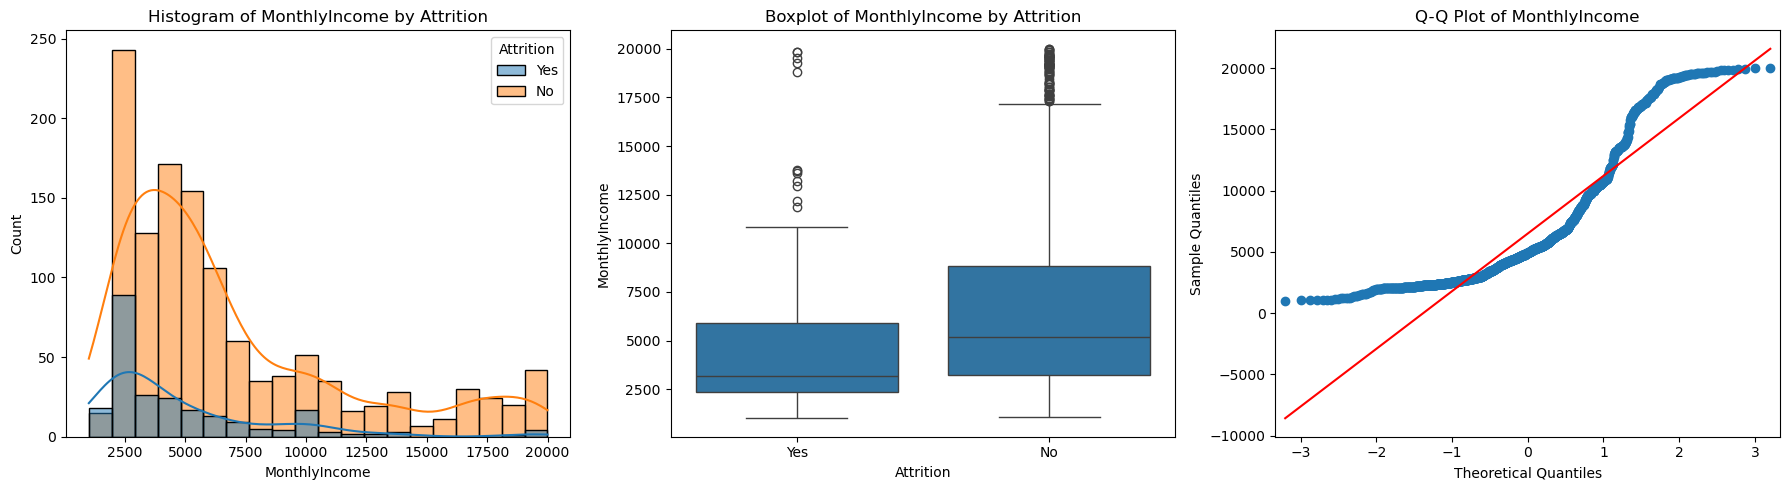

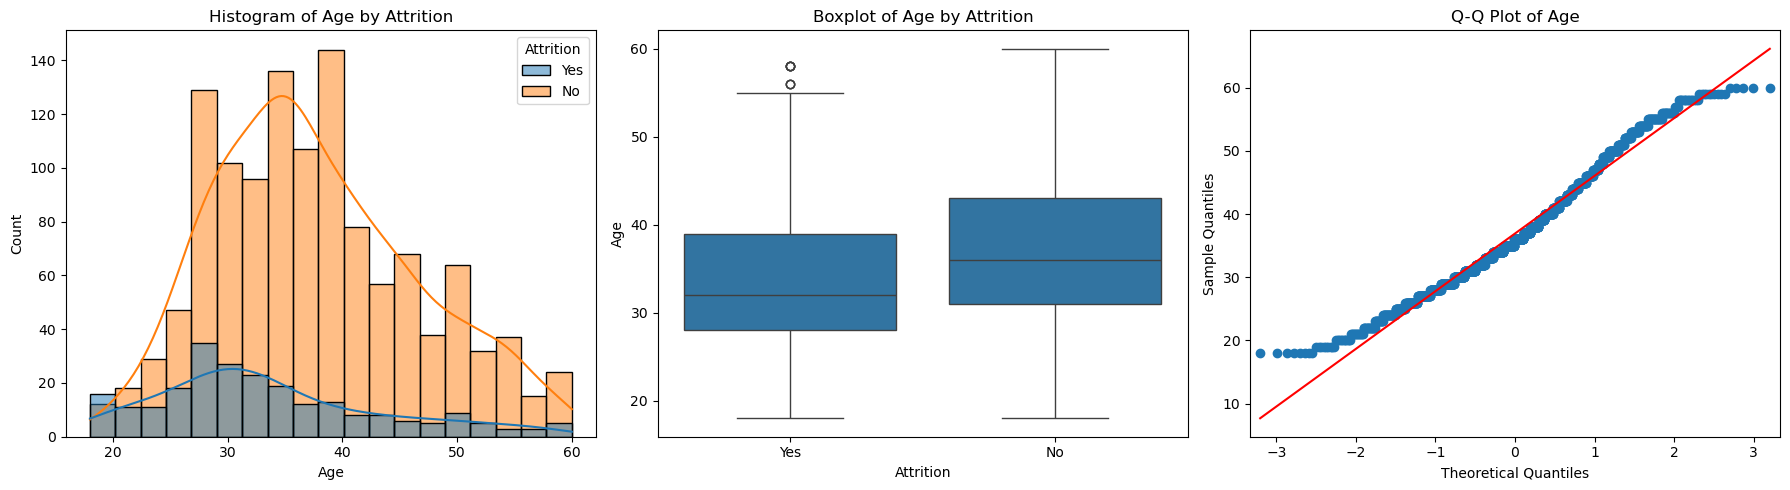

🔍 Shapiro-Wilk Normality Test Results:
MonthlyIncome | Attrition=Yes ➤ W=0.7799, p=1.5025e-17 → ❌ Not Normal Distribution
MonthlyIncome | Attrition=No ➤ W=0.8341, p=5.9704e-34 → ❌ Not Normal Distribution
Age | Attrition=Yes ➤ W=0.9457, p=1.0052e-07 → ❌ Not Normal Distribution
Age | Attrition=No ➤ W=0.9782, p=1.1065e-12 → ❌ Not Normal Distribution

🔍 Kolmogorov-Smirnov Test Results:
MonthlyIncome | Attrition = Yes ➤ D = 0.1798, p = 3.5588e-07 → ❌ Not Normal Distribution
MonthlyIncome | Attrition = No ➤ D = 0.1763, p = 5.4575e-34 → ❌ Not Normal Distribution
Age | Attrition = Yes ➤ D = 0.1199, p = 1.9871e-03 → ❌ Not Normal Distribution
Age | Attrition = No ➤ D = 0.0823, p = 1.0374e-07 → ❌ Not Normal Distribution


### 📌 Final Decision Summary:
- **MonthlyIncome**: ❌ Non-Parametric Test (Mann-Whitney U Test) should be used — Not normal in at least one group
- **Age**: ❌ Non-Parametric Test (Mann-Whitney U Test) should be used — Not normal in at least one group


In [621]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, kstest

# Use relevant columns
df = df[['Attrition', 'MonthlyIncome', 'Age']]

# Step 2: Plot Histograms, Boxplots, Q-Q plots
def plot_distribution(df, column):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram
    sns.histplot(data=df, x=column, hue='Attrition', kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {column} by Attrition')

    # Boxplot
    sns.boxplot(data=df, x='Attrition', y=column, ax=axes[1])
    axes[1].set_title(f'Boxplot of {column} by Attrition')

    # Q-Q plot
    sm.qqplot(df[column], line='s', ax=axes[2])
    axes[2].set_title(f'Q-Q Plot of {column}')

    plt.tight_layout()
    plt.show()

# Plot for both variables
plot_distribution(df, 'MonthlyIncome')
plot_distribution(df, 'Age')

# Step 3: Shapiro-Wilk Test (per group)
print("🔍 Shapiro-Wilk Normality Test Results:")
normality_decision = {}  # To store normality decision per column

for col in ['MonthlyIncome', 'Age']:
    col_is_normal = True  # Assume normal unless any group fails
    for group in ['Yes', 'No']:
        data = df[df['Attrition'] == group][col]
        stat, p = shapiro(data)
        result = "❌ Not Normal Distribution" if p < 0.05 else "✅ Normal Distribution"
        print(f"{col} | Attrition={group} ➤ W={stat:.4f}, p={p:.4e} → {result}")
        if p < 0.05:
            col_is_normal = False
    normality_decision[col] = col_is_normal

# Step 4: Kolmogorov-Smirnov Test
print("\n🔍 Kolmogorov-Smirnov Test Results:")
for col in ['MonthlyIncome', 'Age']:
    for group in ['Yes', 'No']:
        data = df[df['Attrition'] == group][col]
        stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))
        result = "❌ Not Normal Distribution" if p < 0.05 else "✅ Normal Distribution"
        print(f"{col} | Attrition = {group} ➤ D = {stat:.4f}, p = {p:.4e} → {result}")
        if p < 0.05:
            normality_decision[col] = False  # Overwrite if any K-S result is not normal

# ✅ Step 5: Decision Summary
print("\n\n### 📌 Final Decision Summary:")
for col, is_normal in normality_decision.items():
    if is_normal:
        print(f"- **{col}**: ✅ Parametric Test (t-test) can be used — Normal in all groups")
    else:
        print(f"- **{col}**: ❌ Non-Parametric Test (Mann-Whitney U Test) should be used — Not normal in at least one group")


# PART B — Hypothesis Test (Binary Group)
Example Hypothesis:
• H₀: There is no difference in Monthly Income between employees who left and those who
stayed.
• H₁: There is a difference in Monthly Income between the two groups.
If normal: Use Independent Two-Sample t-test
If not normal: Use Mann-Whitney U Test

In [623]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# Columns to test
columns_to_test = ['MonthlyIncome', 'Age']
groups = ['Yes', 'No']

final_results = {}

print("📊 Hypothesis Test Summary:\n")

for col in columns_to_test:
    # Step 1: Split data by Attrition
    group_yes = df[df['Attrition'] == 'Yes'][col]
    group_no = df[df['Attrition'] == 'No'][col]

    # Step 2: Check normality in both groups
    p_yes = shapiro(group_yes)[1]
    p_no = shapiro(group_no)[1]

    # Step 3: Choose test based on normality
    if p_yes > 0.05 and p_no > 0.05:
        # Use t-test
        stat, p = ttest_ind(group_yes, group_no, equal_var=False)
        test_used = "Parametric Test (Independent t-test)"
    else:
        # Use Mann-Whitney U test
        stat, p = mannwhitneyu(group_yes, group_no, alternative='two-sided')
        test_used = "Non-Parametric Test (Mann-Whitney U Test)"

    # Step 4: Store result
    if p < 0.05:
        conclusion = f"➡️ Reject H₀: Significant difference in {col} between employees who left and stayed."
    else:
        conclusion = f"✅ Fail to Reject H₀: No significant difference in {col} between employees who left and stayed."

    final_results[col] = {
        'test': test_used,
        'stat': stat,
        'p': p,
        'conclusion': conclusion
    }

# Step 5: Print Final Report
print("📌 Final Conclusion:\n")
for col, result in final_results.items():
    print(f"🔸 {col}")
    print(f"   • Test Used    : {result['test']}")
    print(f"   • Test Stat    : {result['stat']:.4f}")
    print(f"   • p-value      : {result['p']}")
    print(f"   • Conclusion   : {result['conclusion']}\n")


📊 Hypothesis Test Summary:

📌 Final Conclusion:

🔸 MonthlyIncome
   • Test Used    : Non-Parametric Test (Mann-Whitney U Test)
   • Test Stat    : 100620.5000
   • p-value      : 2.9508309172888725e-14
   • Conclusion   : ➡️ Reject H₀: Significant difference in MonthlyIncome between employees who left and stayed.

🔸 Age
   • Test Used    : Non-Parametric Test (Mann-Whitney U Test)
   • Test Stat    : 106859.0000
   • p-value      : 5.304342075341702e-11
   • Conclusion   : ➡️ Reject H₀: Significant difference in Age between employees who left and stayed.



# PART C — Hypothesis Test (Multiple Groups)
Example Hypothesis:
• H₀: The median job satisfaction is the same across all job roles.
• H₁: At least one job role differs in median job satisfaction.
If normal: Use One-way ANOVA
If not normal: Use Kruskal-Wallis Test

🔍 Shapiro-Wilk Test for Normality (per JobRole):
Sales Executive                ➤ W = 0.8303, p = 0.0000 → ❌ Not Normal
Research Scientist             ➤ W = 0.8417, p = 0.0000 → ❌ Not Normal
Laboratory Technician          ➤ W = 0.8427, p = 0.0000 → ❌ Not Normal
Manufacturing Director         ➤ W = 0.8622, p = 0.0000 → ❌ Not Normal
Healthcare Representative      ➤ W = 0.8313, p = 0.0000 → ❌ Not Normal
Manager                        ➤ W = 0.8426, p = 0.0000 → ❌ Not Normal
Sales Representative           ➤ W = 0.8657, p = 0.0000 → ❌ Not Normal
Research Director              ➤ W = 0.8560, p = 0.0000 → ❌ Not Normal
Human Resources                ➤ W = 0.8670, p = 0.0000 → ❌ Not Normal

📊 Hypothesis Test Result:
Test Used      : Kruskal-Wallis Test
Test Statistic : 3.4506
p-value        : 0.9029890964009861
✅ Fail to Reject H₀: No significant difference in job satisfaction across roles.



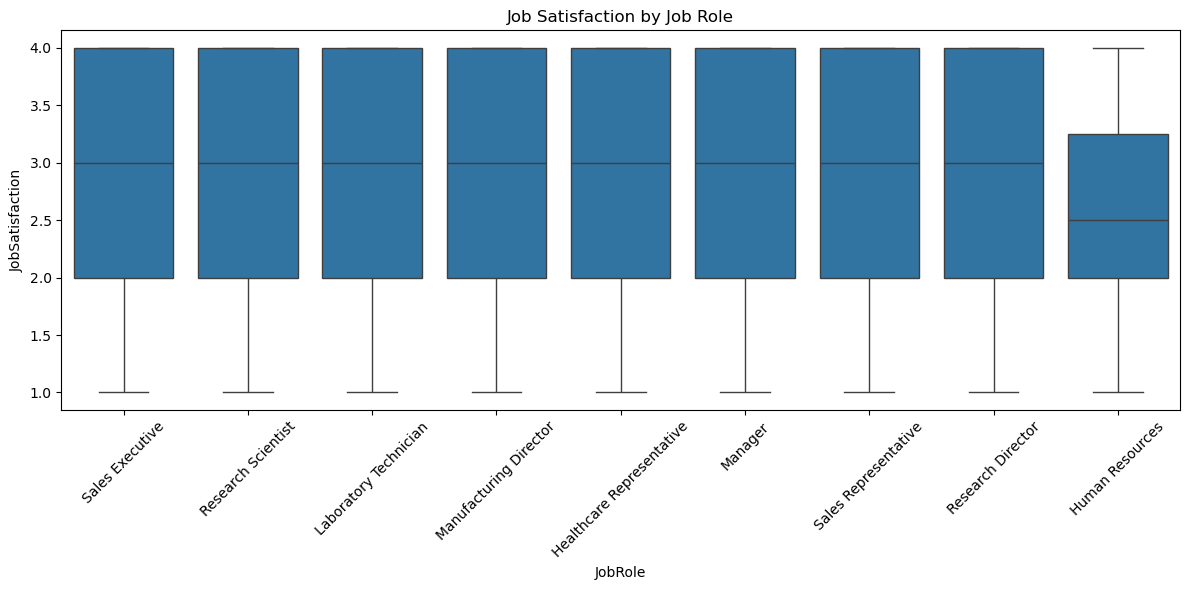

In [625]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway

# Step 1: Subset required columns
df = df1[['JobRole', 'JobSatisfaction']]

# Step 2: Check normality per JobRole using Shapiro-Wilk
print("🔍 Shapiro-Wilk Test for Normality (per JobRole):")
normal_flags = []

for role in df1['JobRole'].unique():
    data = df1[df1['JobRole'] == role]['JobSatisfaction']
    stat, p = shapiro(data)
    is_normal = p > 0.05
    normal_flags.append(is_normal)
    result = "✅ Normal" if is_normal else "❌ Not Normal"
    print(f"{role:<30} ➤ W = {stat:.4f}, p = {p:.4f} → {result}")

# Step 3: Choose test based on normality
if all(normal_flags):
    # All groups are normal → use One-way ANOVA
    test_type = "One-way ANOVA"
    groups = [df1[df1['JobRole'] == role]['JobSatisfaction'] for role in df1['JobRole'].unique()]
    stat, p = f_oneway(*groups)
else:
    # Any group not normal → use Kruskal-Wallis
    test_type = "Kruskal-Wallis Test"
    groups = [df1[df1['JobRole'] == role]['JobSatisfaction'] for role in df1['JobRole'].unique()]
    stat, p = kruskal(*groups)

# Step 4: Decision
print("\n📊 Hypothesis Test Result:")
print(f"Test Used      : {test_type}")
print(f"Test Statistic : {stat:.4f}")
print(f"p-value        : {p}")

if p < 0.05:
    print("❌ Reject H₀: At least one job role differs in job satisfaction.")
else:
    print("✅ Fail to Reject H₀: No significant difference in job satisfaction across roles.\n")

# Step 5: Visualization
plt.figure(figsize=(12,6))
sns.boxplot(data=df1, x='JobRole', y='JobSatisfaction')
plt.title("Job Satisfaction by Job Role")
plt.xticks(rotation=45)
plt.tight_layout();
plt.show();


## 🧾 Final Summary: Hypothesis Test Results

### 🔹 1. Do Monthly Income and Age differ between employees who left vs stayed?

**Test Used:** Mann-Whitney U Test (Non-Parametric)

| Variable        | U Statistic  | p-value       | Conclusion                               |
|----------------|--------------|---------------|------------------------------------------|
| MonthlyIncome  | 100620.5     | 2.95e-14       | ✅ Reject H₀ — Significant difference     |
| Age            | 106859.0     | 5.30e-11       | ✅ Reject H₀ — Significant difference     |

---

### 🔹 2. Does Job Satisfaction differ across Job Roles?

**Test Used:** Kruskal-Wallis Test (Non-Parametric)

| Variable         | Test Statistic | p-value   | Conclusion                                      |
|------------------|----------------|-----------|-------------------------------------------------|
| JobSatisfaction  | 3.4506         | 0.9030    | ❌ Fail to Reject H₀ — No significant difference |

---

### ✅ Interpretation:

- **Monthly Income** and **Age** are **significantly different** between employees who **left** and those who **stayed**.
- **Job Satisfaction** does **not vary significantly** across different job roles.


# Bonus Challenge (Optional)
Compare Age across JobRoles using both parametric and non-parametric tests, and explain:
Which test is more appropriate and why?

🔍 Shapiro-Wilk Test for Normality (per JobRole):
Sales Executive           ➤ W = 0.9490, p = 3.3994e-09 → ❌ Not Normal
Research Scientist        ➤ W = 0.9578, p = 1.7704e-07 → ❌ Not Normal
Laboratory Technician     ➤ W = 0.9752, p = 1.7075e-04 → ❌ Not Normal
Manufacturing Director    ➤ W = 0.9611, p = 4.0136e-04 → ❌ Not Normal
Healthcare Representative ➤ W = 0.9670, p = 2.8045e-03 → ❌ Not Normal
Manager                   ➤ W = 0.9754, p = 5.3366e-02 → ✅ Normal
Sales Representative      ➤ W = 0.9404, p = 7.9010e-04 → ❌ Not Normal
Research Director         ➤ W = 0.9695, p = 5.2629e-02 → ✅ Normal
Human Resources           ➤ W = 0.9738, p = 3.0463e-01 → ✅ Normal

📌 Final Decision Summary:
❌ Not all groups are normal → Use Kruskal-Wallis Test

🧪 One-Way ANOVA Result (Parametric):
F-Statistic = 42.4165, p-value = 2.4641e-61
➡️ Reject H₀: Significant difference in Age across JobRoles

🧪 Kruskal-Wallis Result (Non-Parametric):
H-Statistic = 271.4769, p-value = 4.7768e-54
➡️ Reject H₀: Signific

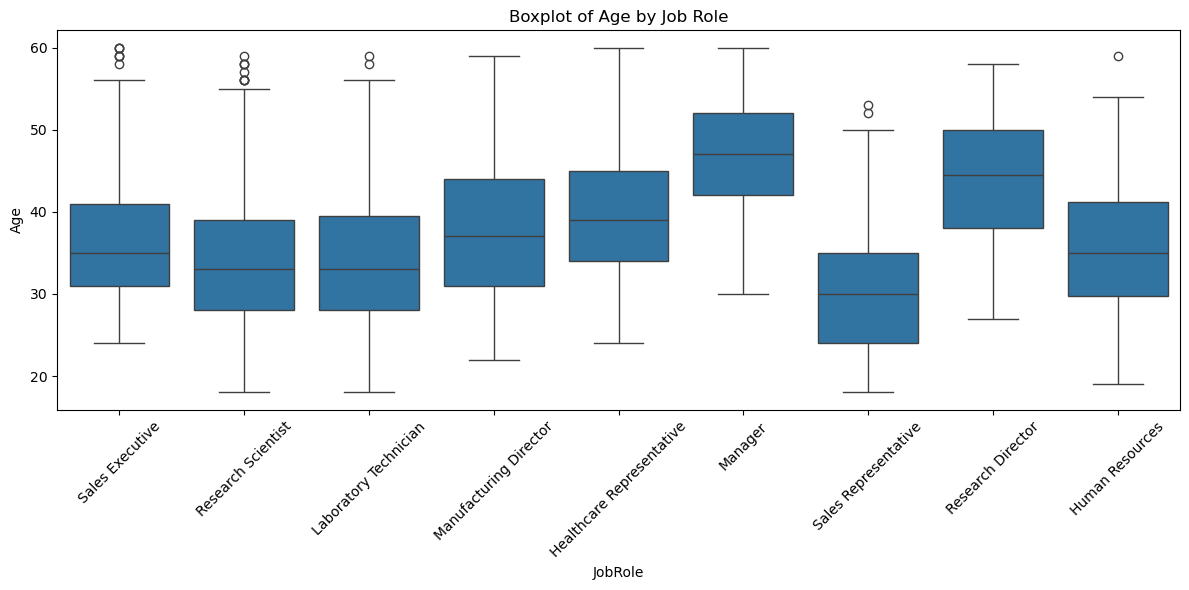

In [628]:

df2 = df2[['JobRole', 'Age']]

# Step 2: Shapiro-Wilk Normality Test per JobRole
print("🔍 Shapiro-Wilk Test for Normality (per JobRole):")
normal_flags = []
for role in df2['JobRole'].unique():
    data = df2[df2['JobRole'] == role]['Age']
    stat, p = shapiro(data)
    is_normal = p > 0.05
    normal_flags.append(is_normal)
    result = "✅ Normal" if is_normal else "❌ Not Normal"
    print(f"{role:<25} ➤ W = {stat:.4f}, p = {p:.4e} → {result}")

# Step 3: Parametric Test (One-Way ANOVA)
anova_groups = [df2[df2['JobRole'] == role]['Age'] for role in df2['JobRole'].unique()]
anova_stat, anova_p = f_oneway(*anova_groups)

# Step 4: Non-Parametric Test (Kruskal-Wallis)
kruskal_stat, kruskal_p = kruskal(*anova_groups)

# Step 5: Decision based on normality
print("\n📌 Final Decision Summary:")
if all(normal_flags):
    print("✅ All groups are normally distributed → Use One-Way ANOVA")
else:
    print("❌ Not all groups are normal → Use Kruskal-Wallis Test")

# Step 6: Print Test Results
print("\n🧪 One-Way ANOVA Result (Parametric):")
print(f"F-Statistic = {anova_stat:.4f}, p-value = {anova_p:.4e}")
if anova_p < 0.05:
    print("➡️ Reject H₀: Significant difference in Age across JobRoles")
else:
    print("✅ Fail to Reject H₀: No significant difference in Age across JobRoles")

print("\n🧪 Kruskal-Wallis Result (Non-Parametric):")
print(f"H-Statistic = {kruskal_stat:.4f}, p-value = {kruskal_p:.4e}")
if kruskal_p < 0.05:
    print("➡️ Reject H₀: Significant difference in Age across JobRoles")
else:
    print("✅ Fail to Reject H₀: No significant difference in Age across JobRoles")

# Step 7: Boxplot for visualization
plt.figure(figsize=(12,6))
sns.boxplot(data=df2, x='JobRole', y='Age')
plt.title("Boxplot of Age by Job Role")
plt.xticks(rotation=45)
plt.tight_layout();
plt.show();